# Практика: VAE и CVAE на MNIST

Этот ноутбук — практическое дополнение к главе 12.2 «Variational Autoencoder (VAE)». Мы соберём VAE с нуля, обучим его на MNIST и своими руками воспроизведём все ключевые картинки главы: реконструкции, семплы из априорного распределения, карту латентного пространства и выученное многообразие. Затем добавим обуславливание на класс цифры и получим CVAE.

Всё считается на CPU за несколько минут — GPU не нужен.

Что нам понадобится:

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cpu")

## Данные

Берём MNIST как есть: картинки $28 \times 28$ с яркостями в $[0, 1]$, вытянутые в векторы длины $784$.

In [2]:
transform = transforms.ToTensor()  # (1, 28, 28), значения в [0, 1]

train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_ds = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256)

print(f"обучающая выборка: {len(train_ds)}, тестовая: {len(test_ds)}")

обучающая выборка: 60000, тестовая: 10000


## Модель

Собираем ровно то, что описано в главе.

**Энкодер** $q_\phi(z \mid x) = \mathcal{N}(\mu_\phi(x), \sigma^2_\phi(x))$ с диагональной матрицей ковариаций: нейросеть по картинке выдаёт вектор средних $\mu$ и логарифмы дисперсий $\log \sigma^2$. Логарифмы — чтобы не заботиться о положительности: $\sigma^2 = \exp(\log \sigma^2) > 0$ автоматически.

**Репараметризация**: $z = \mu_\phi(x) + \varepsilon \cdot \sigma_\phi(x)$, где $\varepsilon \sim \mathcal{N}(0, I)$. Случайность живёт в $\varepsilon$, а градиенты текут по $\mu$ и $\sigma$.

**Декодер** $p_\theta(x \mid z) = \operatorname{Bernoulli}(f_\theta(z))$: яркость пикселя трактуем как параметр распределения Бернулли. Сеть выдаёт логиты, сигмоида из них делает вероятности.

Класс сразу пишем с опциональным условием `cond_dim` — тогда та же реализация подойдёт и для CVAE (там на вход энкодеру и декодеру дополнительно подаётся метка класса).

In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim, cond_dim=0, hidden=512):
        super().__init__()
        self.latent_dim = latent_dim
        self.cond_dim = cond_dim

        # энкодер: (x, y) -> mu, log sigma^2
        self.encoder = nn.Sequential(
            nn.Linear(784 + cond_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2 * latent_dim),
        )
        # декодер: (z, y) -> логиты Бернулли для 784 пикселей
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 784),
        )

    def encode(self, x, y=None):
        h = x if y is None else torch.cat([x, y], dim=1)
        mu, logvar = self.encoder(h).chunk(2, dim=1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y=None):
        h = z if y is None else torch.cat([z, y], dim=1)
        return self.decoder(h)  # логиты

    def forward(self, x, y=None):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, y), mu, logvar

## Функция потерь

Минимизируем $-\text{ELBO}$, то есть сумму двух слагаемых из главы.

**Ошибка восстановления.** Для бернуллиевского декодера

$$-\log p_\theta(x \mid z) = -\sum_{j=1}^{784} \big( x_j \log p_j + (1 - x_j) \log (1 - p_j) \big),$$

то есть обычная бинарная кросс-энтропия, просуммированная по пикселям.

**Регуляризационный член.** Для $q_\phi(z \mid x) = \mathcal{N}(\mu, \operatorname{diag}(\sigma^2))$ и $p(z) = \mathcal{N}(0, I)$ KL-дивергенция считается аналитически:

$$D_{KL} = \frac{1}{2} \sum_{j=1}^{M} \big( \sigma_j^2 + \mu_j^2 - 1 - \ln \sigma_j^2 \big).$$

Коэффициент `beta` перед KL нам понадобится в упражнениях: при `beta=1` это честный ELBO, при `beta=0` — обычный автоэнкодер.

Обратите внимание: число семплов $z$ на объект равно единице — глава объясняет, почему при большом батче этого достаточно.

In [4]:
def elbo_loss(logits, x, mu, logvar, beta=1.0):
    # ошибка восстановления: BCE, просуммированная по пикселям
    recon = F.binary_cross_entropy_with_logits(logits, x, reduction="none").sum(dim=1)
    # KL(N(mu, sigma^2) || N(0, I)) в замкнутой форме
    kl = 0.5 * (mu.pow(2) + logvar.exp() - 1.0 - logvar).sum(dim=1)
    loss = (recon + beta * kl).mean()
    return loss, recon.mean(), kl.mean()

Цикл обучения — совершенно обычный: тот самый «типичный для SGD сетап», о котором говорится в главе после репараметризации.

In [5]:
def train(model, epochs=10, beta=1.0, conditional=False, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(1, epochs + 1):
        model.train()
        sums = np.zeros(3)
        n = 0
        for xb, yb in train_loader:
            x = xb.view(xb.size(0), -1).to(device)
            y = F.one_hot(yb, 10).float().to(device) if conditional else None

            logits, mu, logvar = model(x, y)
            loss, recon, kl = elbo_loss(logits, x, mu, logvar, beta)

            opt.zero_grad()
            loss.backward()
            opt.step()

            bs = x.size(0)
            sums += np.array([loss.item(), recon.item(), kl.item()]) * bs
            n += bs

        loss_, recon_, kl_ = sums / n
        print(f"эпоха {epoch:2d} | -ELBO {loss_:7.2f} | восстановление {recon_:7.2f} | KL {kl_:6.2f}")
    return model

Пара вспомогательных функций для картинок:

In [6]:
def show_grid(imgs, nrow, ncol, title=None, figsize=(8, 4)):
    """imgs: тензор (nrow*ncol, 784) со значениями в [0, 1]"""
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize)
    for ax, img in zip(np.array(axes).flat, imgs):
        ax.imshow(img.view(28, 28).detach().numpy(), cmap="gray")
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def sample_from_prior(model, n=16, label=None):
    """Семплируем z ~ N(0, I) и прогоняем через декодер."""
    model.eval()
    z = torch.randn(n, model.latent_dim)
    y = None
    if label is not None:
        y = F.one_hot(torch.full((n,), label), 10).float()
    return torch.sigmoid(model.decode(z, y))

## VAE с двумерным латентным пространством

Начнём с $M = 2$: такое латентное пространство легко визуализировать целиком — именно так сделаны картинки в главе.

In [7]:
vae2 = VAE(latent_dim=2).to(device)
train(vae2, epochs=10)

эпоха  1 | -ELBO  199.97 | восстановление  193.92 | KL   6.04


эпоха  2 | -ELBO  172.81 | восстановление  167.52 | KL   5.29


эпоха  3 | -ELBO  166.21 | восстановление  160.89 | KL   5.31


эпоха  4 | -ELBO  162.94 | восстановление  157.52 | KL   5.42


эпоха  5 | -ELBO  160.90 | восстановление  155.41 | KL   5.49


...

эпоха  7 | -ELBO  158.21 | восстановление  152.63 | KL   5.58


эпоха  8 | -ELBO  157.28 | восстановление  151.66 | KL   5.63


эпоха  9 | -ELBO  156.47 | восстановление  150.81 | KL   5.66


эпоха 10 | -ELBO  155.80 | восстановление  150.11 | KL   5.69


VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=784, bias=True)
  )
)

### Реконструкции

Прогоним тестовые картинки через энкодер и декодер. Верхний ряд — оригиналы, нижний — то, что модель восстановила из латентного кода.

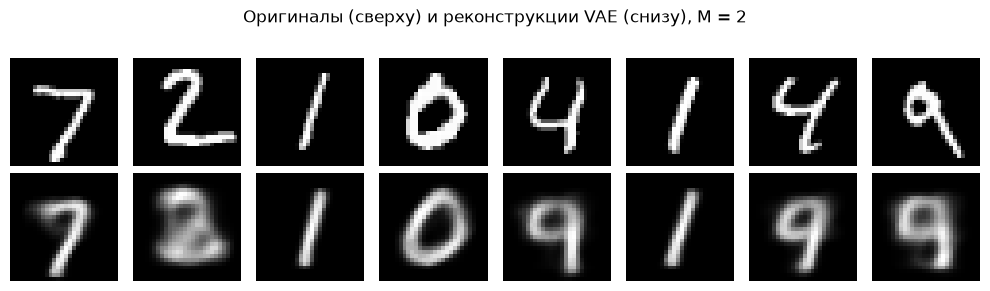

In [8]:
x_test = next(iter(test_loader))[0][:8].view(8, -1)

with torch.no_grad():
    vae2.eval()
    logits, _, _ = vae2(x_test)
    recon = torch.sigmoid(logits)

show_grid(torch.cat([x_test, recon]), nrow=2, ncol=8,
          title="Оригиналы (сверху) и реконструкции VAE (снизу), M = 2", figsize=(10, 3))

### Семплы из априорного распределения

Здесь энкодер уже не нужен: берём $z \sim \mathcal{N}(0, I)$ и подаём прямо в декодер. Именно так и генерирует обученный VAE.

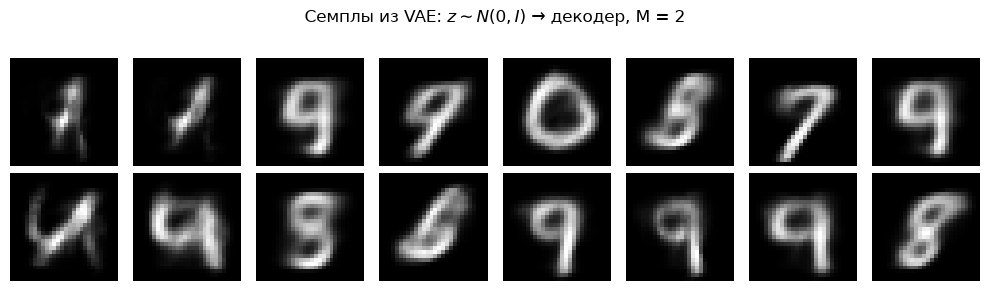

In [9]:
show_grid(sample_from_prior(vae2, n=16), nrow=2, ncol=8,
          title="Семплы из VAE: $z \\sim N(0, I)$ → декодер, M = 2", figsize=(10, 3))

Цифры узнаваемые, но размытые — ровно та размытость, о которой говорится во врезке про условную независимость пикселей.

### Карта латентного пространства

Закодируем всю тестовую выборку и посмотрим, куда попадают коды цифр разных классов. Это воспроизведение картинки из главы про распределение латентных кодов MNIST.

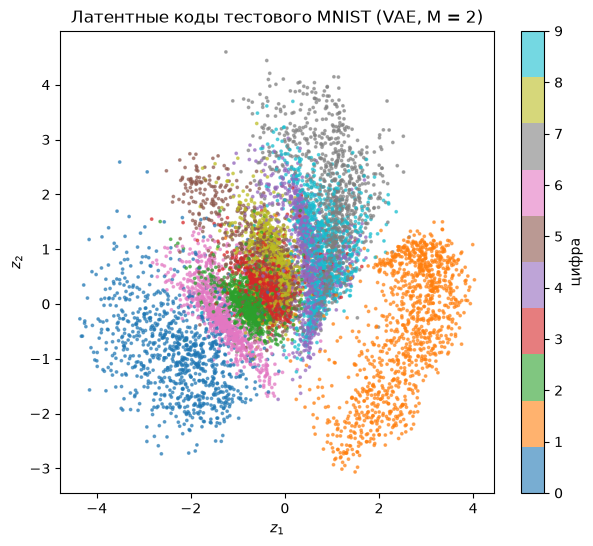

In [10]:
@torch.no_grad()
def latent_scatter(model, conditional=False, title=""):
    model.eval()
    codes, labels = [], []
    for xb, yb in test_loader:
        x = xb.view(xb.size(0), -1)
        y = F.one_hot(yb, 10).float() if conditional else None
        mu, _ = model.encode(x, y)
        codes.append(mu)
        labels.append(yb)
    z = torch.cat(codes).numpy()
    y = torch.cat(labels).numpy()

    plt.figure(figsize=(7, 6))
    sc = plt.scatter(z[:, 0], z[:, 1], c=y, cmap="tab10", s=3, alpha=0.6)
    plt.colorbar(sc, ticks=range(10), label="цифра")
    plt.xlabel("$z_1$")
    plt.ylabel("$z_2$")
    plt.title(title)
    plt.show()


latent_scatter(vae2, title="Латентные коды тестового MNIST (VAE, M = 2)")

Посмотрите, какие классы модель разнесла далеко друг от друга, а какие перепутала. В главе отмечено, что нули и единицы разделяются лучше всего, а тройки и восьмёрки — хуже всего; сравните со своей картинкой.

### Выученное многообразие

Тот самый приём из главы: берём равномерную сетку на квадрате $[0,1]^2$ и применяем к ней $\Phi^{-1}$ — функцию, обратную к CDF стандартного нормального распределения. Полученные точки приближённо распределены как $\mathcal{N}(0, I)$, то есть покрывают априорное распределение «по-честному». Осталось прогнать их через декодер.

В PyTorch $\Phi^{-1}$ — это `torch.special.ndtri`.

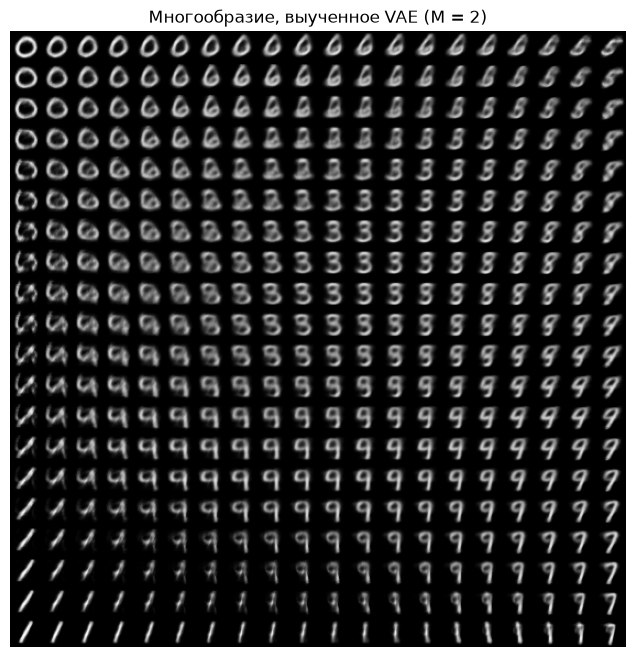

In [11]:
@torch.no_grad()
def plot_manifold(model, n=20, label=None, title="", figsize=(8, 8)):
    model.eval()
    u = torch.linspace(0.02, 0.98, n)
    grid = torch.special.ndtri(u)  # квантили N(0, 1) на равномерной сетке

    canvas = np.zeros((28 * n, 28 * n))
    for i, zi in enumerate(grid):
        z = torch.stack([zi.repeat(n), grid], dim=1)  # (n, 2)
        y = None
        if label is not None:
            y = F.one_hot(torch.full((n,), label), 10).float()
        imgs = torch.sigmoid(model.decode(z, y)).view(n, 28, 28).numpy()
        for j in range(n):
            canvas[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = imgs[j]

    plt.figure(figsize=figsize)
    plt.imshow(canvas, cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()


plot_manifold(vae2, n=20, title="Многообразие, выученное VAE (M = 2)")

Обратите внимание на плавные переходы между цифрами: соседние точки латентного пространства декодируются в похожие картинки. Найдите на своей картинке переход от шестёрок к нулям или от семёрок к единицам — в главе он тоже отмечен.

## Как размерность латента влияет на качество

В главе показано, что заметный скачок качества происходит между $M = 2$ и $M = 5$, а дальше рост размерности почти ничего не даёт. Проверим первую половину этого утверждения: обучим модель с $M = 16$ и сравним семплы.

эпоха  1 | -ELBO  182.14 | восстановление  169.44 | KL  12.70


эпоха  2 | -ELBO  127.62 | восстановление  108.09 | KL  19.52


эпоха  3 | -ELBO  118.14 | восстановление   96.81 | KL  21.33


эпоха  4 | -ELBO  114.40 | восстановление   92.48 | KL  21.91


эпоха  5 | -ELBO  112.13 | восстановление   89.86 | KL  22.27


эпоха  6 | -ELBO  110.61 | восстановление   88.10 | KL  22.51


эпоха  7 | -ELBO  109.61 | восстановление   86.92 | KL  22.69


эпоха  8 | -ELBO  108.72 | восстановление   85.89 | KL  22.83


эпоха  9 | -ELBO  108.03 | восстановление   85.10 | KL  22.94


эпоха 10 | -ELBO  107.52 | восстановление   84.49 | KL  23.03


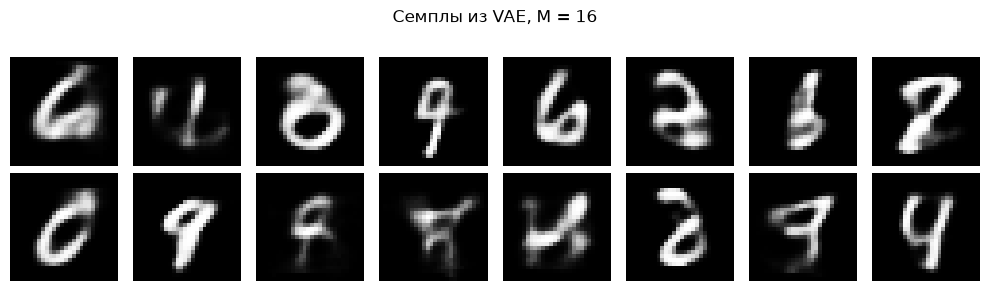

In [12]:
vae16 = VAE(latent_dim=16).to(device)
train(vae16, epochs=10)

show_grid(sample_from_prior(vae16, n=16), nrow=2, ncol=8,
          title="Семплы из VAE, M = 16", figsize=(10, 3))

Семплы должны стать заметно осмысленнее: двумерного латента просто не хватает, чтобы закодировать всё разнообразие рукописных цифр.

## CVAE: обуславливание на класс

Теперь научимся генерировать не «какую-нибудь» цифру, а заданную. Как сказано в главе, на уровне реализации это делается предельно просто: конкатенируем вход энкодера и декодера с one-hot вектором метки — именно для этого мы и заложили `cond_dim`.

Модель обучается на всех классах сразу и веса у неё общие — это не то же самое, что десять независимых VAE.

In [13]:
cvae = VAE(latent_dim=2, cond_dim=10).to(device)
train(cvae, epochs=10, conditional=True)

эпоха  1 | -ELBO  192.80 | восстановление  185.45 | KL   7.34


эпоха  2 | -ELBO  149.55 | восстановление  145.09 | KL   4.45


эпоха  3 | -ELBO  143.04 | восстановление  138.75 | KL   4.29


эпоха  4 | -ELBO  140.46 | восстановление  136.18 | KL   4.28


эпоха  5 | -ELBO  138.86 | восстановление  134.56 | KL   4.29


...

эпоха  7 | -ELBO  136.73 | восстановление  132.38 | KL   4.34


эпоха  8 | -ELBO  135.93 | восстановление  131.57 | KL   4.36


эпоха  9 | -ELBO  135.30 | восстановление  130.92 | KL   4.37


эпоха 10 | -ELBO  134.74 | восстановление  130.33 | KL   4.41


VAE(
  (encoder): Sequential(
    (0): Linear(in_features=794, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=784, bias=True)
  )
)

### Генерация заданной цифры

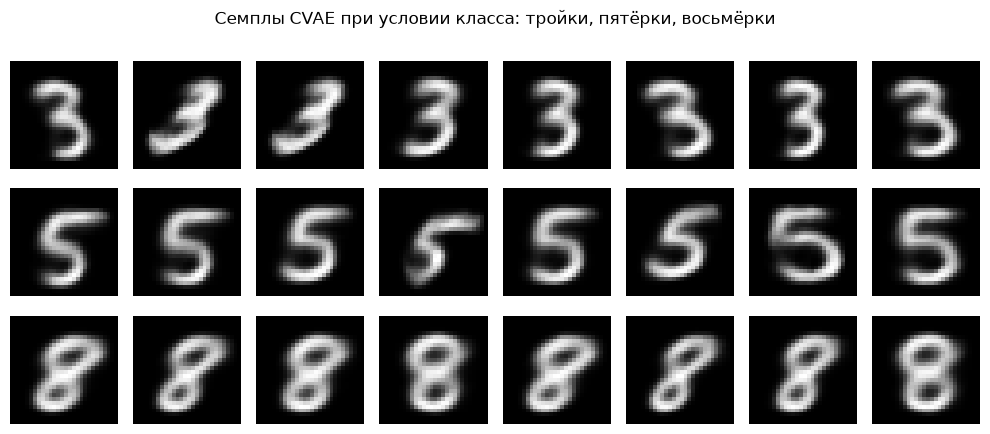

In [14]:
rows = [sample_from_prior(cvae, n=8, label=digit) for digit in [3, 5, 8]]
show_grid(torch.cat(rows), nrow=3, ncol=8,
          title="Семплы CVAE при условии класса: тройки, пятёрки, восьмёрки", figsize=(10, 4.5))

Качество каждой отдельной цифры заметно выше, чем у безусловного VAE с тем же двумерным латентом: модели больше не нужно тратить латентное пространство на то, чтобы различать классы, — класс ей сообщают явно. Латент теперь кодирует только «почерк»: наклон, толщину, форму.

### Латентное пространство CVAE

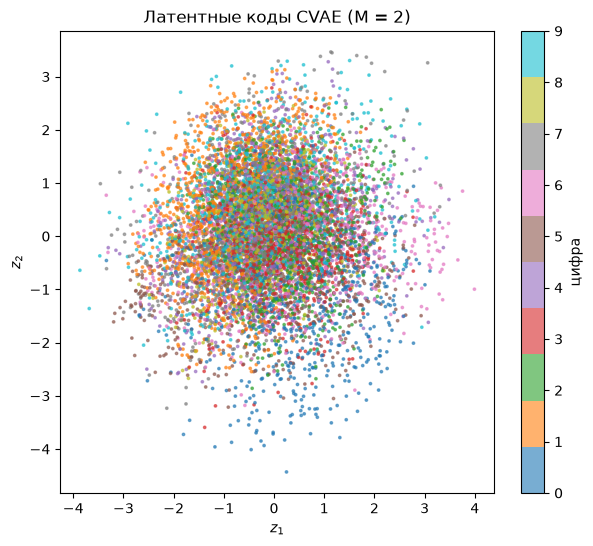

In [15]:
latent_scatter(cvae, conditional=True, title="Латентные коды CVAE (M = 2)")

Кластеры по классам пропали — вместо них бесформенное облако. Это ровно та картинка, которая приведена в главе, и она не должна пугать: у каждой цифры теперь своё априорное распределение $p(z \mid y) = \mathcal{N}(0, I)$, а классы разделяет не латент, а условие $y$.

Убедимся в этом, построив многообразие при фиксированном классе:

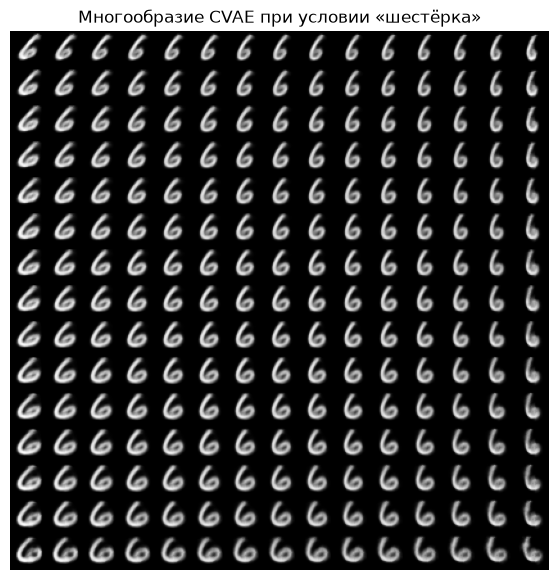

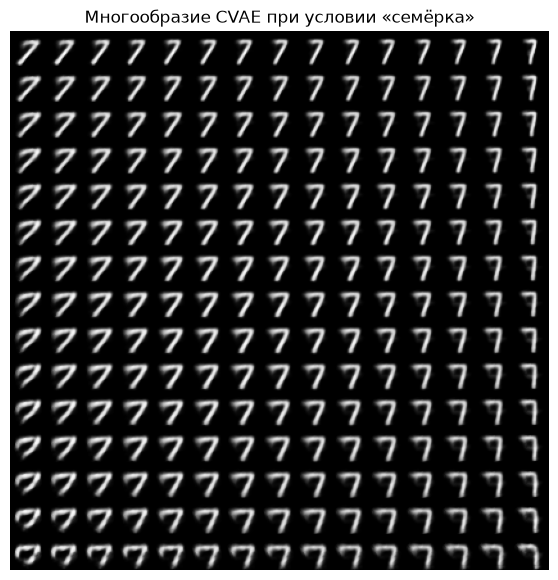

In [16]:
plot_manifold(cvae, n=15, label=6, title="Многообразие CVAE при условии «шестёрка»", figsize=(7, 7))
plot_manifold(cvae, n=15, label=7, title="Многообразие CVAE при условии «семёрка»", figsize=(7, 7))

Одна и та же область латентного пространства при разных условиях декодируется в разные цифры, а внутри одного класса латент плавно меняет начертание.

## Упражнения

**Упражнение 1 (главное).** Обучите модель с `beta=0`, то есть выкинув из функции потерь KL-слагаемое, — получится обычный автоэнкодер. Постройте для неё реконструкции и семплы из $\mathcal{N}(0, I)$.

Вы увидите, что реконструкции стали *лучше* (модели больше ничто не мешает), а семплы из априорного распределения превратились в мусор. Это в точности та ситуация, которая описана в главе для VQ-VAE: без регуляризационного члена распределение кодов ничем не притянуто к априорному, и семплировать из него нельзя. Постройте `latent_scatter` для этой модели и посмотрите, куда уехали коды и каков их масштаб.

**Упражнение 2.** Попробуйте `beta=4` ($\beta$-VAE). Как меняется баланс между качеством реконструкции и «правильностью» латентного пространства? Сравните значения `восстановление` и `KL` в логах обучения.

**Упражнение 3.** Воспроизведите картинку из главы про размерность латентного пространства целиком: обучите модели с $M \in \{2, 5, 10, 20\}$ и выведите семплы из каждой рядом. Действительно ли основной скачок происходит между 2 и 5?

**Упражнение 4.** Замените бернуллиевский декодер на гауссовский с фиксированной дисперсией: ошибка восстановления станет суммой квадратов отклонений (см. задачу про гауссовский декодер в главе). Что произойдёт с картинками? Подсказка: $\sigma^2$ неявно работает как вес $\beta$ перед KL-слагаемым.

**Упражнение 5.** Обусловьте CVAE не на метку класса, а на верхнюю половину картинки (в главе упоминается, что $y$ может быть произвольным тензором). Модель должна научиться дорисовывать нижнюю половину цифры. Что нужно поменять? Только `cond_dim` и то, что вы конкатенируете, — вся остальная реализация останется прежней.